
# 1.2.4 BT thực hành 2 - Pima_indians_diabetes

## Giới thiệu về dataset bệnh tiểu đường

Tập dữ liệu này được lấy từ Kaggle, chứa thông tin y tế của phụ nữ thuộc tộc người Pima sống tại Arizona, Hoa Kỳ. Mục tiêu của dữ liệu là hỗ trợ phân tích và dự đoán khả năng mắc bệnh tiểu đường dựa trên các chỉ số sức khỏe.

a. Mục tiêu sử dụng
- Phân tích đặc điểm bệnh lý tiểu đường

- Xây dựng mô hình dự đoán nguy cơ mắc bệnh

- Thực hành các kỹ thuật EDA, trực quan hóa và học máy

b. Các biến chính trong dữ liệu
- Pregnancies: Số lần mang thai

- Glucose: Nồng độ glucose trong máu

- BloodPressure: Huyết áp

- SkinThickness: Độ dày da

- Insulin: Mức insulin

- BMI: Chỉ số khối cơ thể

- DiabetesPedigreeFunction: Chỉ số di truyền liên quan đến tiểu đường

- Age: Tuổi

- Outcome: Biến mục tiêu (1: có tiểu đường, 0: không)

c. Đặc điểm nổi bật
- Dữ liệu đã được chuẩn hóa, không chứa giá trị thiếu

- Phù hợp để thực hành phân tích đơn biến, hai biến, trực quan hóa và xây dựng mô hình phân loại

- Là một trong những tập dữ liệu kinh điển trong lĩnh vực y tế và học máy

d. Ứng dụng thực tế
- Hỗ trợ bác sĩ và chuyên gia y tế đánh giá nguy cơ bệnh tiểu đường

- Là nguồn dữ liệu lý tưởng để giảng dạy và thực hành các kỹ thuật phân tích dữ liệu y tế

- Có thể áp dụng các mô hình như Logistic Regression, Decision Tree, Random Forest, XGBoost để dự đoán Outcome

## 1. Chuẩn bị dữ liệu cho trực quan hóa dữ liệu

In [3]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv('dataset/diabetes.csv')

# Xem sơ bộ
df.info()
print("Số lượng dòng (bản ghi):", df.shape[0])
print("Số lượng cột (biến):", df.shape[1])

# Bước chuẩn bị dữ liệu
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)  # Thay 0 bằng NaN
df.fillna(df.median(), inplace=True)  # Điền thiếu bằng trung vị

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Số lượng dòng (bản ghi): 768
Số lượng cột (biến): 9


## 2. Thiết lập kiểu hiển thị cho toàn bộ biểu đồ

In [4]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Biểu đồ phân phối (Histogram + KDE)

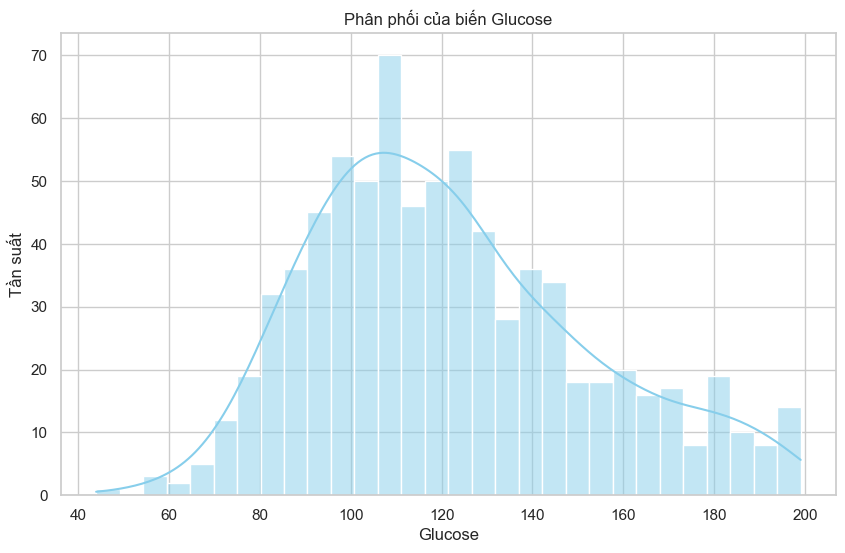

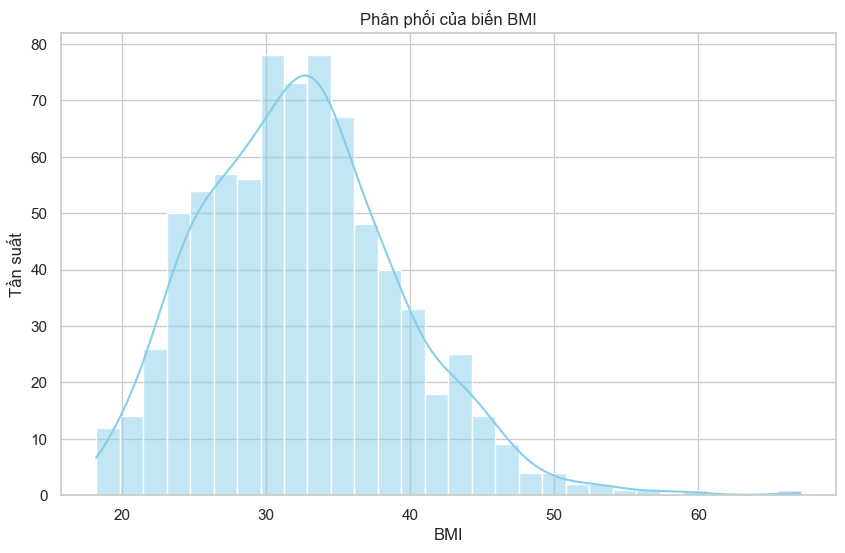

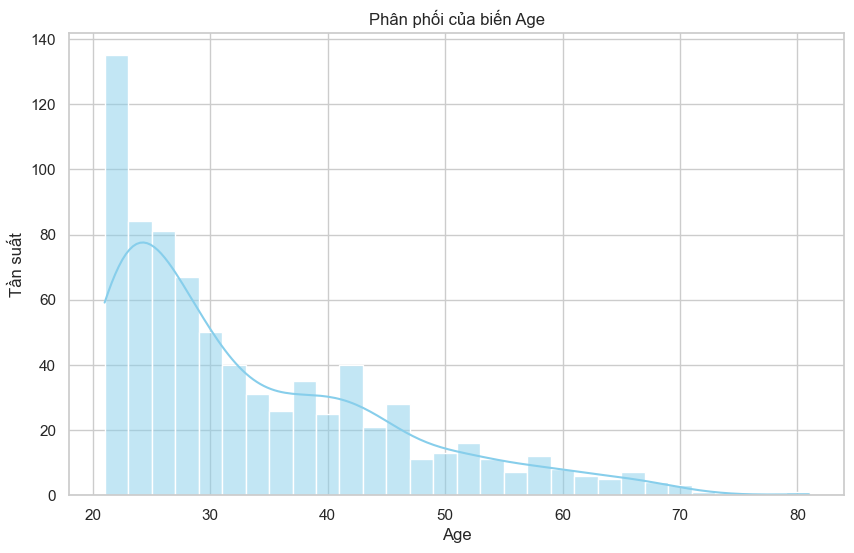

In [5]:
features = ['Glucose', 'BMI', 'Age']
for feature in features:
    plt.figure()
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của biến {feature}')
    plt.xlabel(feature)
    plt.ylabel('Tần suất')
    plt.show()

### Nhận xét:
#### - Biểu đồ phân phối Glucose
Biểu đồ cho thấy phân phối Glucose lệch phải, với phần lớn giá trị tập trung quanh mức 110–120. Điều này phản ánh xu hướng phổ biến về mức đường huyết trong tập dữ liệu.

#### - Biểu đồ phân phối BMI
BMI có phân phối lệch phải nhẹ, với đỉnh ở khoảng 27. Đây là mức phổ biến trong cộng đồng, nhưng cũng cảnh báo nguy cơ thừa cân ở một số cá nhân.

#### - Biểu đồ phân phối Age
Tuổi có phân phối lệch phải rõ rệt, phần lớn người trong tập dữ liệu nằm ở độ tuổi dưới 40. Điều này cho thấy mẫu nghiên cứu thiên về nhóm người trẻ.

## 4. Biểu đồ hộp (Boxplot) theo Outcome

C:\Users\ACER\AppData\Local\Temp\ipykernel_28252\4118264589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='Glucose', palette='Set2')


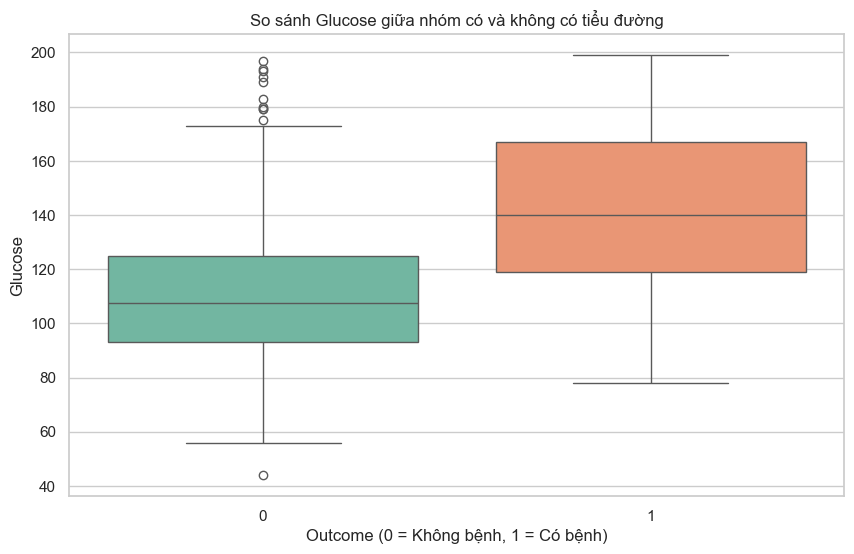

In [6]:
plt.figure()
sns.boxplot(data=df, x='Outcome', y='Glucose', palette='Set2')
plt.title('So sánh Glucose giữa nhóm có và không có tiểu đường')
plt.xlabel('Outcome (0 = Không bệnh, 1 = Có bệnh)')
plt.ylabel('Glucose')
plt.show()

### Nhận xét:
#### - Biểu đồ hộp Glucose theo Outcome
Người mắc tiểu đường (Outcome = 1) có mức Glucose trung bình cao hơn rõ rệt so với người không mắc bệnh. Biểu đồ cũng cho thấy nhiều giá trị ngoại lai ở cả hai nhóm.

## 5. Biểu đồ tương quan (Heatmap)

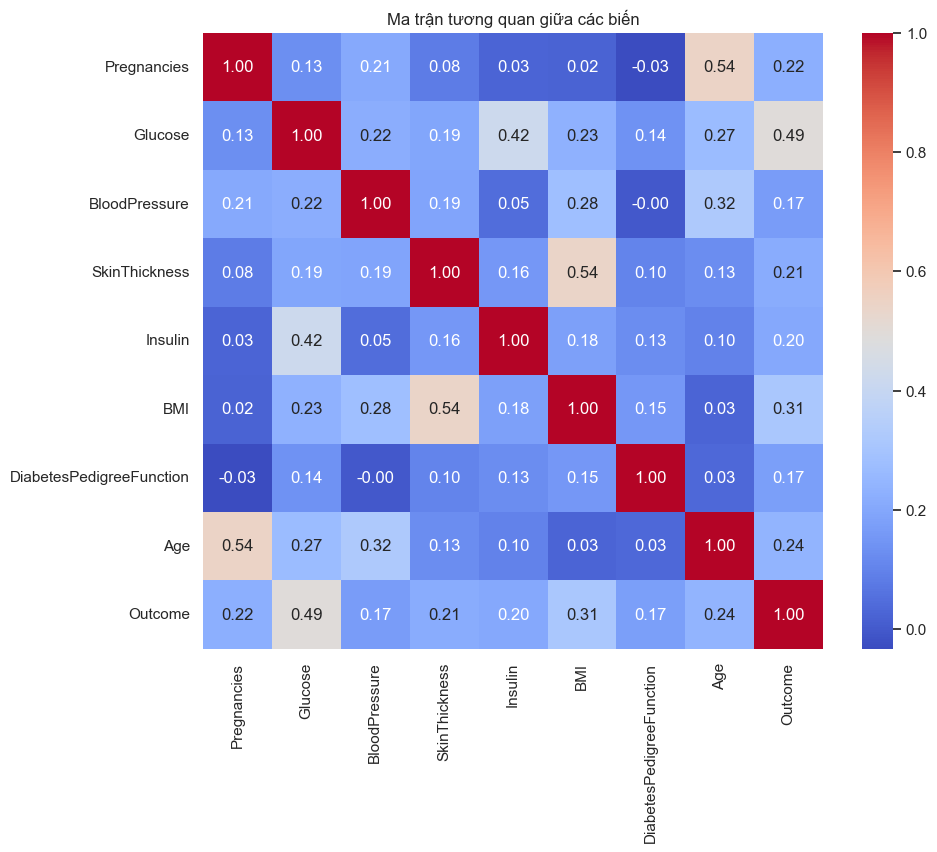

In [7]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến')
plt.show()

### Nhận xét:
#### - Biểu đồ tương quan (Heatmap)
Biểu đồ cho thấy Glucose có mối tương quan cao nhất với Outcome (0.49), tiếp theo là BMI và Age. Những biến này thể hiện mối liên hệ rõ ràng với khả năng mắc tiểu đường, và có thể đóng vai trò quan trọng trong việc phân tích hoặc xây dựng mô hình dự báo.

## 6. Biểu đồ đếm (Countplot) theo Outcome

C:\Users\ACER\AppData\Local\Temp\ipykernel_28252\2964551746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='pastel')


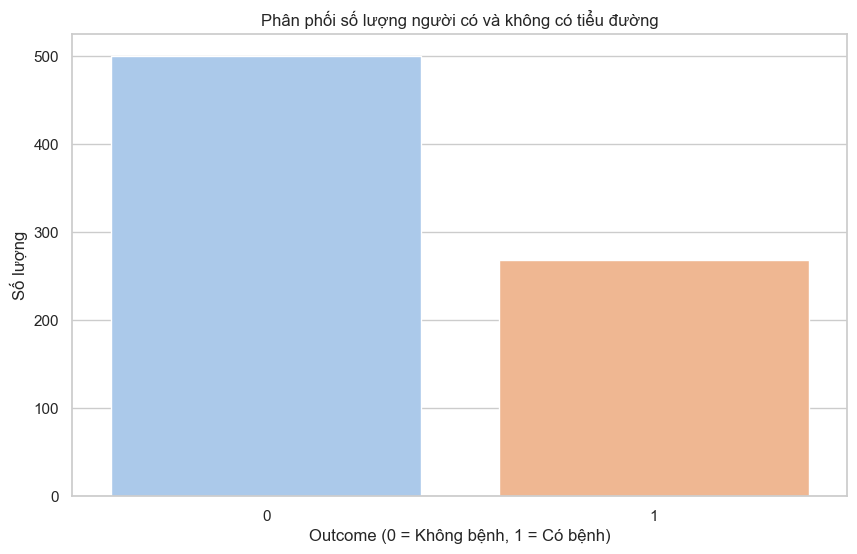

In [8]:
plt.figure()
sns.countplot(data=df, x='Outcome', palette='pastel')
plt.title('Phân phối số lượng người có và không có tiểu đường')
plt.xlabel('Outcome (0 = Không bệnh, 1 = Có bệnh)')
plt.ylabel('Số lượng')
plt.show()

### Nhận xét:
#### - Biểu đồ đếm (Countplot theo Outcome)
Biểu đồ cho thấy số lượng người không mắc tiểu đường (Outcome = 0) chiếm phần lớn trong tập dữ liệu, với hơn 500 người, trong khi nhóm mắc tiểu đường (Outcome = 1) chỉ khoảng hơn 300. Điều này phản ánh sự mất cân bằng nhãn trong dữ liệu, cần lưu ý nếu sử dụng cho mô hình học máy.

## 7. Biểu đồ phân tán (Scatter plot) theo theo Glucose và BMI

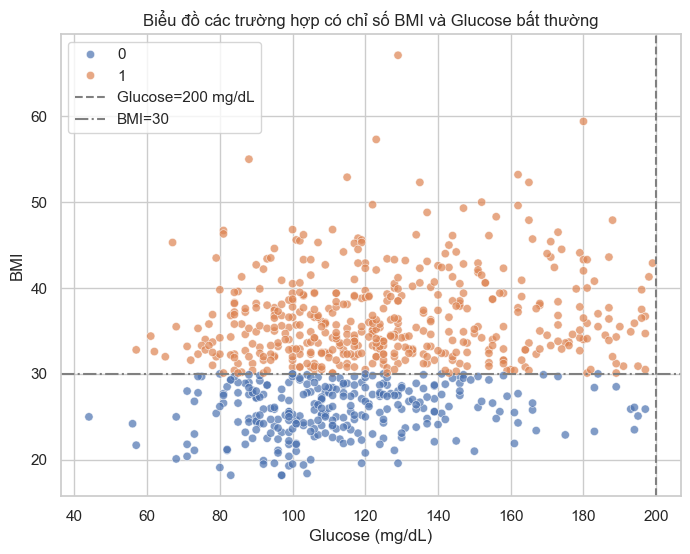

In [ ]:
df['HighRisk'] = ((df['Glucose'] > 200) | (df['BMI'] >   30)).astype(int)

# Scatter plot Glucose vs BMI
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Glucose',
    y='BMI',
    hue='HighRisk',       # 1 = giả định mắc bệnh, 0 = không
    alpha=0.7
)
plt.axvline(200, color='gray', linestyle='--', label='Glucose=200 mg/dL')
plt.axhline(30, color='gray', linestyle='-.', label='BMI=30')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('BMI')
plt.title('Biểu đồ các trường hợp có chỉ số BMI và Glucose bất thường')
plt.legend()

### Nhận xét:
#### - Biểu đồ phân tán (Scatter plot) theo theo Glucose và BMI
Biểu đồ cho thấy sự phân bố chỉ số Glucose và BMI giữa hai nhóm người (Outcome = 0 và Outcome = 1). Nhóm không mắc tiểu đường (Outcome = 0) có xu hướng tập trung ở vùng chỉ số Glucose < 200 và BMI < 30, trong khi nhóm mắc tiểu đường (Outcome = 1) xuất hiện nhiều hơn ở vùng vượt ngưỡng (BMI > 30) nhưng không ai có mức glucose vượt 200 mg/dL. Điều này phản ánh sự khác biệt rõ rệt về đặc điểm sức khỏe giữa hai nhóm, đồng thời cho thấy các ngưỡng Glucose và BMI có thể đóng vai trò phân tách trong phân tích dữ liệu y tế.